# 실습 5-1 : Feature Selection (mRMR, Boruta)

#### **<실습 개요>**

1. 다중공선성 확인 : 상관행렬 히트맵 시각화
2. mRMR 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
3. Boruta 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
4. 성능 비교 요약 : 전체 변수 vs mRMR vs Boruta

## 분석 준비

### 주요 라이브러리 호출

In [2]:
# mRMR, boruta 설치
!uv add mrmr-selection boruta

Resolved 389 packages in 34ms
Checked 354 packages in 1.77s


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

# 회귀 모델 및 성능 평가 지표
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 데이터 분할
from sklearn.model_selection import train_test_split

# Boruta 내부에서 변수 중요도를 계산할 때 사용하는 앙상블 모델
from sklearn.ensemble import RandomForestRegressor

In [4]:
# 회귀 성능 평가 함수 (이후 전체 변수 / mRMR / Boruta 결과를 같은 기준으로 비교하기 위해 정의)
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1) 데이터 준비

- 공정 중 여러 구간에서 수집한 센서 통계값(표준편차, 평균, 범위)으로 최종 계측값(Y)을 예측하는 회귀 데이터셋

In [5]:
data = pd.read_csv(("dataset/day5-1_data.csv"), encoding="EUC-KR")
data

,자재구분,END_DATE_TIME,Y,CHAMBER,TAE.STDDEV0,TAE.MEAN0,TAE.RANGE0,PC.STDDEV0,PC.MEAN0,PC.RANGE0,...,TAE.STDDEV9,TAE.MEAN9,TAE.RANGE9,CROT.STDDEV9,CROT.MEAN9,CROT.RANGE9,PC.STDDEV9,PC.MEAN9,PC.RANGE9,PC.RANGE11.1
0,1,2017-09-25 16:18,69,4,0.044554,38.083127,0.254154,0.124753,0.044329,0.439883,...,0.032832,35.011650,0.127077,0,35,0,0.405343,45.124841,3.079182,NaN
1,2,2017-09-25 16:13,28,2,0.034801,38.052395,0.063538,0.177575,0.342131,0.439883,...,0.020858,35.550245,0.063540,0,27,0,1.923012,45.350277,15.004887,NaN
2,3,2017-09-25 16:15,13,3,0.030089,38.046407,0.127080,0.137559,0.063983,0.488759,...,0.021635,36.013373,0.063538,0,15,0,0.161640,45.071393,0.977516,NaN
3,4,2017-09-25 16:10,101,4,0.047904,38.090810,0.190617,1.441465,0.503421,6.549365,...,0.025405,35.020727,0.127077,0,35,0,0.359273,45.110758,2.688171,NaN
4,5,2017-10-05 3:48,319,3,0.036058,38.023829,0.190617,0.116419,0.045446,0.391007,...,0.076083,33.967311,0.317697,0,58,0,0.447676,45.147192,3.225808,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,135,2018-01-25 13:18,27,3,0.027780,38.064804,0.063536,0.306206,0.342131,1.124145,...,0.025479,36.533647,0.127079,0,65,0,0.325076,45.069147,3.176930,3.176930
135,136,2018-01-25 13:10,23,3,0.033961,38.077084,0.063536,0.163848,0.502723,0.488759,...,0.033529,36.548598,0.127079,0,64,0,0.668920,45.131644,5.180838,5.180838
136,137,2018-01-25 13:13,56,3,0.031002,38.068007,0.063536,0.177190,0.481776,0.537634,...,0.026805,36.535092,0.127079,0,64,0,0.613599,44.972303,4.985336,4.985336
137,138,2018-01-25 13:15,78,2,0.031002,38.068007,0.063536,0.170316,0.349113,0.439883,...,0.038289,36.022728,0.127080,0,22,0,1.382720,45.285845,10.801564,10.801564


### 1-1) 전처리

In [6]:
# 식별자, 시간 정보 컬럼과 결측치가 있는 컬럼 제거
data.drop(["자재구분", "END_DATE_TIME"], axis=1, inplace=True)
data.dropna(axis=1, inplace=True)

# 값이 모두 동일해 분산이 0인 변수는 모델 학습에 아무 정보도 주지 못하므로 제거
for col in data.columns:
    if len(data[col].unique()) == 1:
        data.drop([col], axis=1, inplace=True)

print("최종 데이터 크기:", data.shape)

최종 데이터 크기: (139, 117)


In [7]:
X = data.drop("Y", axis=1)
Y = data["Y"]

# random_state를 고정해 이후 mRMR/Boruta 비교 실험이 동일한 학습/검증 데이터로 진행되도록 함
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

---

### 1-2) 다중공선성 확인

> **다중공선성(Multicollinearity)**
>
> 입력변수 간 상관관계가 높아 모델의 안정성과 해석력이 저하되는 현상
>
> **해결 방법**
>
> 차원 축소(Dimensionality Reduction)
> - Feature Selection : mRMR, Boruta
> - Feature Extraction : PCA

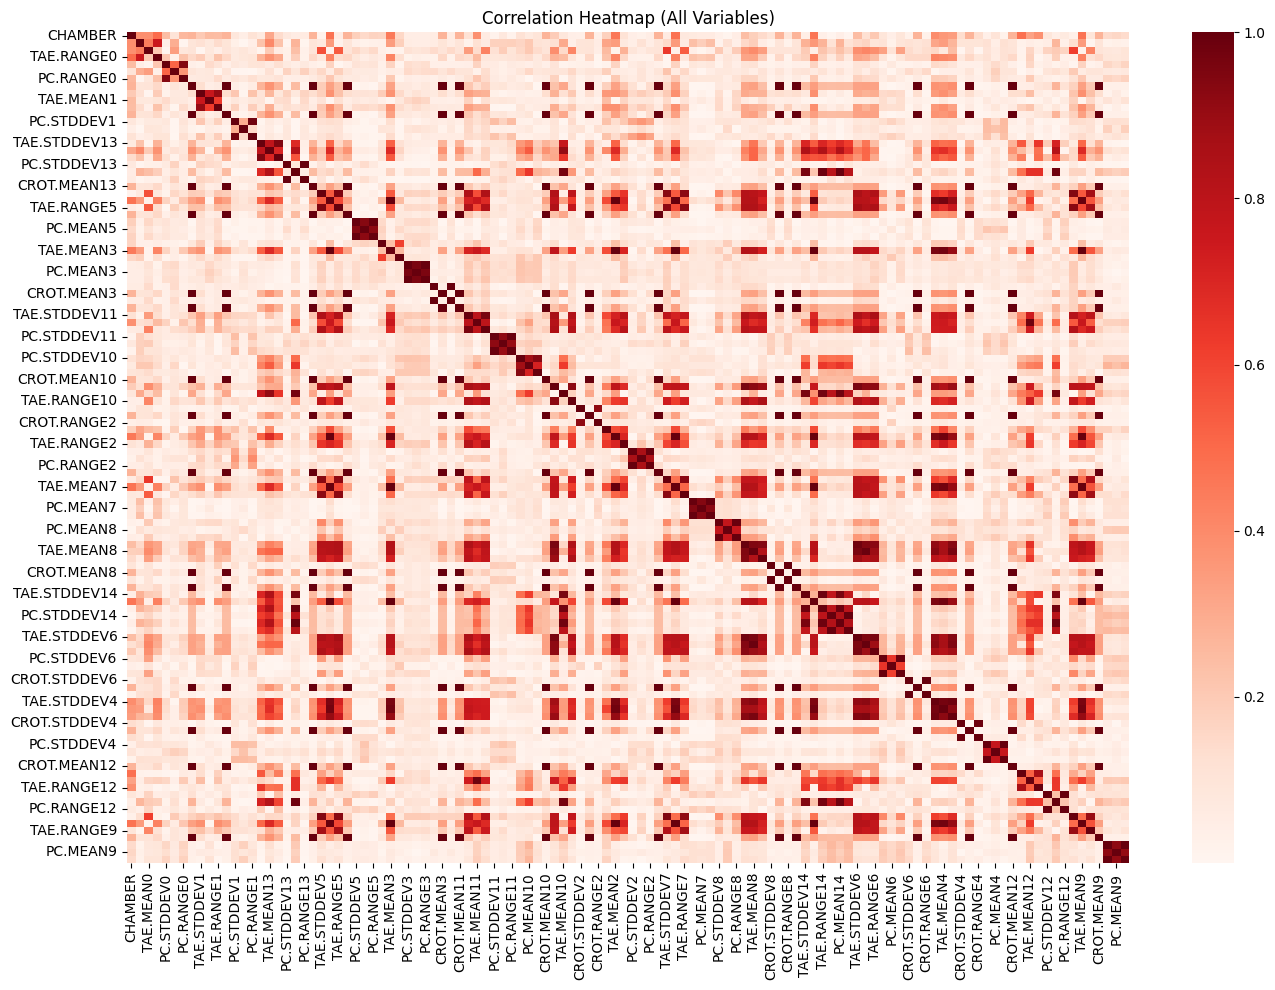

In [8]:
plt.figure(figsize=(14, 10))
sns.heatmap(abs(X.corr()), cmap='Reds')
plt.title("Correlation Heatmap (All Variables)")
plt.tight_layout()
plt.show()

In [9]:
# 변수 선택 전 baseline 성능 (이후 mRMR/Boruta 결과와 비교할 기준점)
lr_all = LinearRegression()
lr_all.fit(X_train, Y_train)
pred_all = lr_all.predict(X_test)
print("[전체 변수 사용]")
get_regscore(Y_test, pred_all)

[전체 변수 사용]
MSE       : 94210.388
MAE       : 213.011
R-squared : -15.511


---

## 2) 변수 선택법 적용

### 2-1) mRMR

> **mRMR**
>
> 입력변수들 간의 상관관계는 **최소화(Minimum Redundancy)** 하고, 입력변수와 출력변수 간의 상관관계는 **최대화(Maximum Relevance)** 하는 변수 선택 방법
> - Pearson 상관계수를 사용하여 변수 간 관계를 파악
> - 하이퍼파라미터 $k$: 선택할 변수의 개수

In [10]:
from mrmr import mrmr_regression

# mRMR로 상위 k개 변수 선택 (하이퍼파라미터)
k = 15
selected_mrmr = mrmr_regression(X_train, Y_train, K=k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

100%|██████████| 15/15 [00:01<00:00, 13.24it/s]

mRMR 선택 변수 (15개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13']
mRMR 제거 변수 : 101개 (전체 116개 중 15개만 사용)


In [11]:
# mRMR 기반으로 선택된 변수만으로 다시 학습해 성능 추출
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train)
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])
print("[mRMR 선택 변수 사용]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용]
MSE       : 4494.179
MAE       : 44.956
R-squared : 0.212


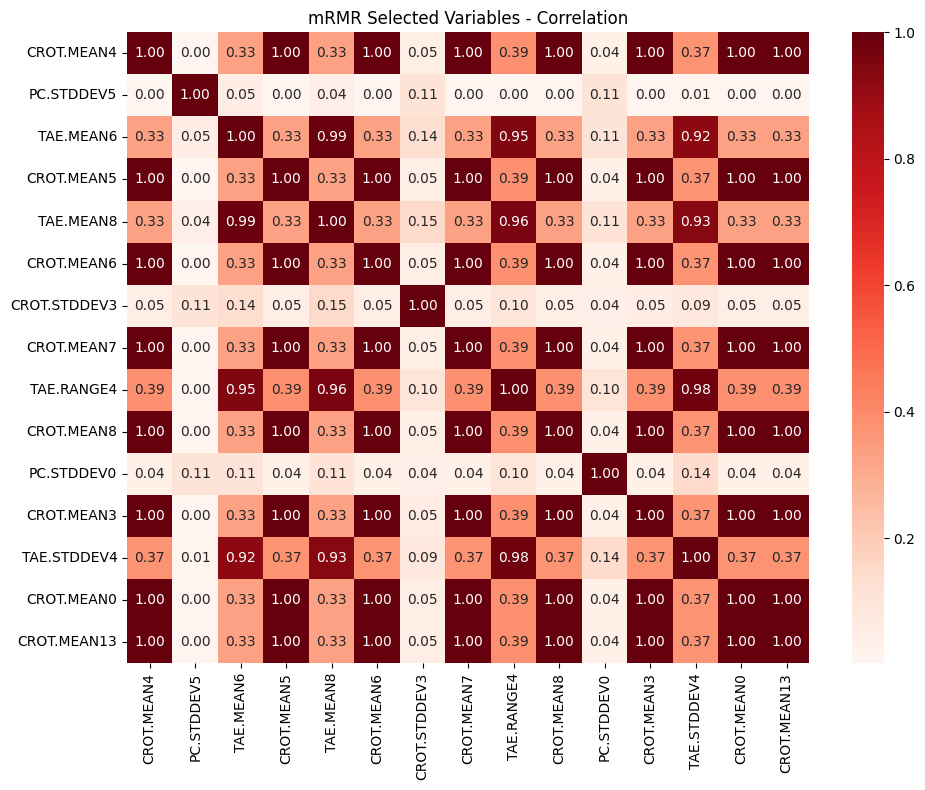

In [12]:
# mRMR 적용 이후 Heatmap 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [13]:
# k-fold cross validation을 활용해 후보 k값들 중 최적의 k값 찾기
k_candidates = [3, 5, 7, 10, 15]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_scores = {}

for k in k_candidates:
    # 전체 학습 데이터 기준으로 mRMR 변수 선택 
    selected = mrmr_regression(X_train, Y_train, K=k)
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][selected], X_train.iloc[val_idx][selected]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred)) # MSE 기준
    
    k_scores[k] = np.mean(fold_scores)
    print(f"k={k}, 변수={selected}, 평균 MSE={k_scores[k]:.4f}")

100%|██████████| 3/3 [00:00<00:00, 22.82it/s]


k=3, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6'], 평균 MSE=1827.2074


100%|██████████| 5/5 [00:00<00:00, 14.20it/s]


k=5, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8'], 평균 MSE=1919.6131


100%|██████████| 7/7 [00:00<00:00, 17.98it/s]


k=7, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3'], 평균 MSE=1961.4725


100%|██████████| 10/10 [00:00<00:00, 20.83it/s]


k=10, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8'], 평균 MSE=2199.8306


100%|██████████| 15/15 [00:00<00:00, 19.85it/s]

k=15, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13'], 평균 MSE=2696.1711


In [14]:
# 가장 성능 좋은(MSE 최소) k 선택
best_k = min(k_scores, key=k_scores.get)
print(f"최적 k: {best_k} (MSE={k_scores[best_k]:.4f})")

# 최적 k로 최종 변수 선택
selected_mrmr = mrmr_regression(X_train, Y_train, K=best_k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

최적 k: 3 (MSE=1827.2074)


100%|██████████| 3/3 [00:00<00:00, 15.10it/s]

mRMR 선택 변수 (3개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
mRMR 제거 변수 : 113개 (전체 116개 중 3개만 사용)


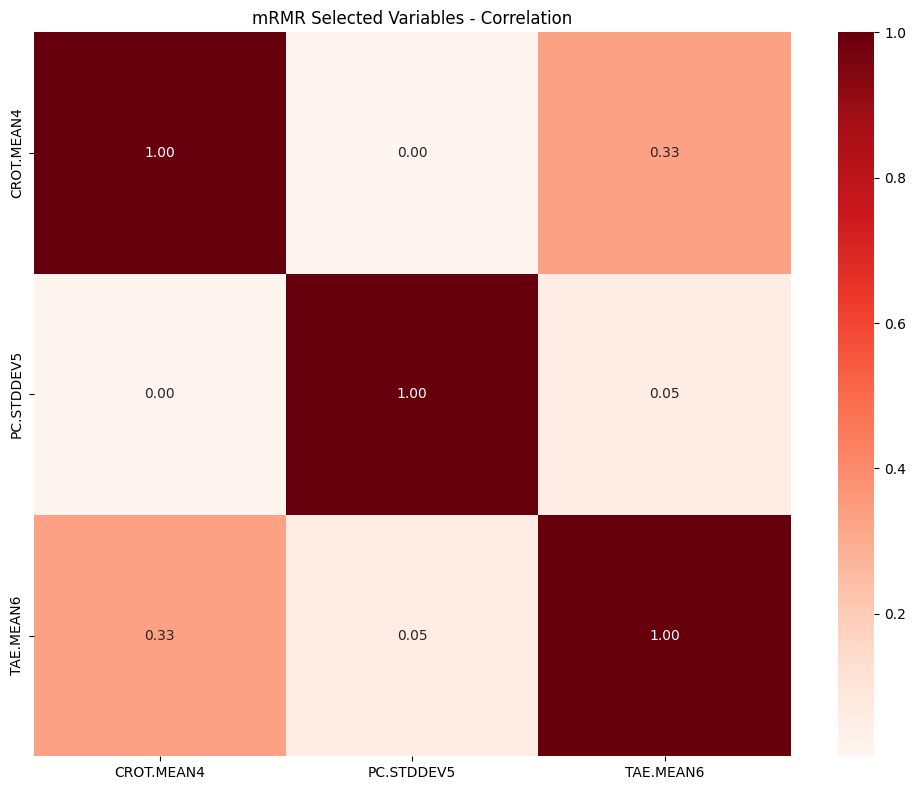

In [15]:
# mRMR를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [16]:
# best_k 변수로 최종 학습 후 X_test 성능 평가
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train) 
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])

print("[mRMR 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용 - Test 성능]
MSE       : 3731.451
MAE       : 40.361
R-squared : 0.346


---

### 2-2) Boruta

> **Boruta**
>
> 출력변수를 예측하는 데 필요한 **모든 관련 변수(All Relevant Features)** 를 선택하는 방법
>
> - 입력변수의 값을 무작위로 섞은 **Shadow Feature**를 생성
> - Random Forest로 변수 중요도를 계산하여 Shadow Feature 보다 높은 중요도를 가진 변수만 선택

In [17]:
from boruta import BorutaPy

# n_estimators='auto' : 트리 개수 자동 설정
# max_iter=10 : 반복 판단 횟수 (많을수록 정확하지만 느림)
# perc=100 : 판단 기준 엄격도 (100=가장 엄격, 낮을수록 변수 더 많이 통과)

rf = RandomForestRegressor(random_state=42)
selected_boruta = BorutaPy(rf, n_estimators='auto', max_iter=10, perc=100, random_state=42)

# BorutaPy는 numpy 배열만 지원 -> DataFrame을 values로 변환
# Y는 1차원 배열이어야 하므로 ravel() 적용
selected_boruta.fit(X_train.values, Y_train.values.ravel())

print("총 변수:", X.shape[1])
print("Boruta 확정 변수:", selected_boruta.n_features_)

총 변수: 116
Boruta 확정 변수: 1


> Bourta의 3가지 판단 상태

| 상태 | 의미 | 관련 속성 |
|---|---|---|
| 확정 (Confirmed) | 진짜 유의미한 변수라고 확실히 판단 | `support_` |
| 미정 (Tentative) | 유의미한지 애매하게 끝남 | `support_weak_` |
| 기각 (Rejected) | 의미 없다고 판단 | 둘 다 False |

In [18]:
# 확정 변수(support_)와 판단이 애매한 미정 변수(support_weak_)를 구분해서 확인
boruta_cols = X_train.columns[selected_boruta.support_].tolist()
boruta_tentative = X_train.columns[selected_boruta.support_weak_].tolist()

# 미정 변수 중요도 계산용 랜덤포레스트를 데이터 전체로 별도 학습 (Boruta 내부 rf와 별개)
rf_importance = RandomForestRegressor(random_state=42)
rf_importance.fit(X_train, Y_train)
importances = rf_importance.feature_importances_

tentative_ranked = sorted(boruta_tentative, key=lambda c: importances[X_train.columns.get_loc(c)], reverse=True)

print("확정 변수:", boruta_cols)
print("미정 변수(중요도 순):", tentative_ranked)

확정 변수: ['TAE.MEAN7']
미정 변수(중요도 순): ['TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']


In [19]:
# 미정 변수를 0개~5개까지 추가하며 k-fold로 성능 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_candidates = range(0, min(5, len(tentative_ranked)) + 1)

n_scores = {}

for n in n_candidates:
    use_cols = boruta_cols + tentative_ranked[:n]
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][use_cols], X_train.iloc[val_idx][use_cols]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred))
    
    n_scores[n] = np.mean(fold_scores)
    print(f"미정 변수 {n}개 추가, 평균 MSE={n_scores[n]:.4f}")

미정 변수 0개 추가, 평균 MSE=2530.5618
미정 변수 1개 추가, 평균 MSE=2525.6161
미정 변수 2개 추가, 평균 MSE=2515.9683
미정 변수 3개 추가, 평균 MSE=2675.1350
미정 변수 4개 추가, 평균 MSE=2503.8725
미정 변수 5개 추가, 평균 MSE=2014.0646


In [20]:
# 최적 개수 선택
best_n = min(n_scores, key=n_scores.get)
print(f"최적 미정 변수 개수: {best_n} (MSE={n_scores[best_n]:.4f})")

최적 미정 변수 개수: 5 (MSE=2014.0646)


In [21]:
# 최적 조합으로 최종 학습 및 Test 평가
selected_boruta_final = boruta_cols + tentative_ranked[:best_n]
print(f"최종 사용 변수 ({len(use_cols)}개):", use_cols)

lr_boruta = LinearRegression()
lr_boruta.fit(X_train[selected_boruta_final], Y_train)
pred_boruta = lr_boruta.predict(X_test[selected_boruta_final])
print("[Boruta 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_boruta)

최종 사용 변수 (6개): ['TAE.MEAN7', 'TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']
[Boruta 선택 변수 사용 - Test 성능]
MSE       : 3890.515
MAE       : 40.315
R-squared : 0.318


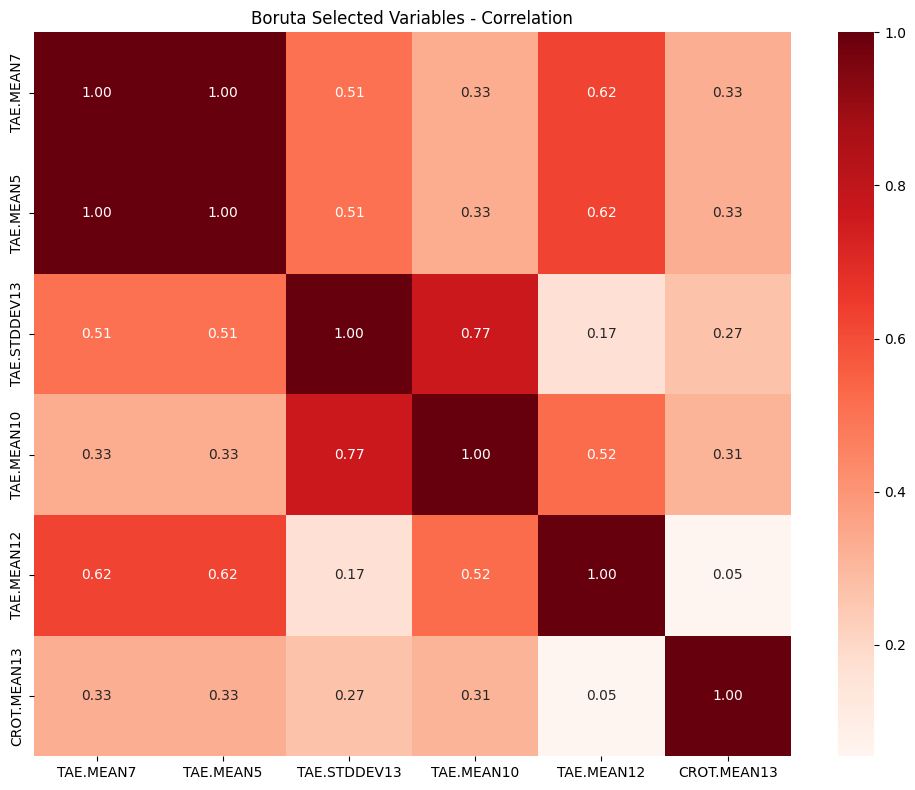

In [22]:
# Boruta를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_boruta_final].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("Boruta Selected Variables - Correlation")
plt.tight_layout()
plt.show()

### 2-3) 성능 비교 요약

In [23]:
results = pd.DataFrame({
    "Method": ["전체 변수", f"mRMR (k={best_k})", f"Boruta ({len(selected_boruta_final)}개)"],
    "변수 수": [X.shape[1], best_k, len(use_cols)],
    "MAE": [
        round(mean_absolute_error(Y_test, pred_all), 2),
        round(mean_absolute_error(Y_test, pred_mrmr), 2),
        round(mean_absolute_error(Y_test, pred_boruta), 2)
    ],
    "R-squared": [
        round(r2_score(Y_test, pred_all), 3),
        round(r2_score(Y_test, pred_mrmr), 3),
        round(r2_score(Y_test, pred_boruta), 3)
    ]
})

results

,Method,변수 수,MAE,R-squared
0,전체 변수,116,213.01,-15.511
1,mRMR (k=3),3,40.36,0.346
2,Boruta (6개),6,40.32,0.318


> **분류 문제였다면?**
>
> - mRMR은 `mrmr_regression` → `mrmr_classif`
> - Boruta는 `RandomForestRegressor` → `RandomForestClassifier`

---

## 3) Vibe Coding 실습

**[과제 1]** 

지수는 mRMR과 Boruta가 서로 다른 원리로 변수를 선택한다는 것을 배웠습니다.

AI와 함께 동일한 데이터에 mRMR과 Boruta를 적용하여 선택된 변수를 비교해 보세요. 

두 방법에서 공통으로 선택된 변수와 한 방법에서만 선택된 변수를 확인하고 왜 이러한 차이가 발생했는지 AI와 토의하여 해석해 보세요.

In [26]:
!uv add borutashap mrmr-selection shap-hypetune catboost xicorpy


Resolved 394 packages in 8.98s
Prepared 1 package in 268ms
Installed 1 package in 49ms
 + shap-hypetune==0.1.1


**[과제 1 추가] BorutaShap + CatBoost**

Boruta와 유사하게 Shadow Feature와 중요도 비교를 수행하되, **CatBoost + SHAP** 기반 중요도(`importance_measure='shap'`)를 사용합니다. 섹션 2의 mRMR·Boruta 결과와 함께 3가지 방법을 비교합니다.

In [32]:
# ============================================================
# [과제 1] BorutaShap + CatBoost 변수 선택
# ============================================================
import numpy as np
import scipy.stats as stats

# scipy / numpy 호환 (BorutaShap 구버전 의존성)
if not hasattr(np, "NaN"):
    np.NaN = np.nan
if not hasattr(stats, "binom_test"):
    from scipy.stats import binomtest

    def binom_test(k, n, p=0.5, alternative="two-sided"):
        return binomtest(int(k), int(n), p, alternative=alternative).pvalue

    stats.binom_test = binom_test

from BorutaShap import BorutaShap
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    
    iterations=300, depth=6, learning_rate=0.05, random_state=42, verbose=0
)
bs_selector = BorutaShap(
    model=cat_model, importance_measure="shap", classification=False
)
bs_selector.fit(
    X=X_train, y=Y_train, n_trials=50, sample=True, random_state=42, verbose=False
)

borutashap_accepted = list(bs_selector.accepted)
borutashap_tentative = list(bs_selector.tentative)

# Boruta 섹션과 동일: tentative 변수는 RF 중요도 순으로 정렬
if borutashap_tentative:
    rf_bs = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_bs.fit(X_train[borutashap_tentative], Y_train)
    tentative_bs_ranked = (
        pd.Series(rf_bs.feature_importances_, index=borutashap_tentative)
        .sort_values(ascending=False)
        .index.tolist()
    )
else:
    tentative_bs_ranked = []

selected_borutashap = borutashap_accepted + tentative_bs_ranked

print(f"BorutaShap 확정 ({len(borutashap_accepted)}개): {borutashap_accepted}")
print(f"BorutaShap 미정 ({len(borutashap_tentative)}개): {borutashap_tentative}")
print(f"BorutaShap 최종 ({len(selected_borutashap)}개): {selected_borutashap}")

100%|██████████| 50/50 [01:27<00:00,  1.75s/it]

BorutaShap 확정 (0개): []
BorutaShap 미정 (5개): ['CROT.MEAN4', 'CROT.MEAN2', 'TAE.MEAN3', 'TAE.STDDEV13', 'CROT.MEAN9']
BorutaShap 최종 (5개): ['TAE.STDDEV13', 'TAE.MEAN3', 'CROT.MEAN4', 'CROT.MEAN2', 'CROT.MEAN9']


**[과제 1 추가] mRMR (Chatterjee Xi)**

섹션 2의 mRMR은 **Pearson 상관**을 Relevance·Redundancy에 사용합니다.  
여기서는 **Chatterjee Xi(ξ) 상관계수**를 동일한 mRMR 프레임워크에 적용합니다.

- **Chatterjee Xi**: 단조(monotonic) 관계까지 포착하는 **비모수** 의존성 지표 (0~1)
- **동일 k=best_k** 로 Pearson mRMR과 공정 비교
- `xicorpy.compute_xi_correlation` 사용

In [33]:
# ============================================================
# [과제 1] mRMR (Chatterjee Xi) 변수 선택
# - Relevance / Redundancy 모두 Chatterjee Xi(ξ) 사용
# - 섹션 2 Pearson mRMR과 동일 k=best_k
# ============================================================
import xicorpy
from mrmr import mrmr_regression


def _xi_score(x, y):
    mask = ~(pd.isna(x) | pd.isna(y))
    if mask.sum() < 3:
        return 0.0
    return abs(float(xicorpy.compute_xi_correlation(x[mask].values, y[mask].values)))


def xi_relevance(X, y):
    return pd.Series({col: _xi_score(X[col], y) for col in X.columns})


def xi_redundancy(target_column, features, X):
    target = X[target_column]
    return pd.Series({col: _xi_score(X[col], target) for col in features})


selected_mrmr_xi = mrmr_regression(
    X_train,
    Y_train,
    K=best_k,
    relevance=xi_relevance,
    redundancy=xi_redundancy,
    show_progress=True,
)

common_mrmr = sorted(set(selected_mrmr) & set(selected_mrmr_xi))
print(f"mRMR (Pearson) 선택 ({len(selected_mrmr)}개, k={best_k}): {selected_mrmr}")
print(f"mRMR (Chatterjee) 선택 ({len(selected_mrmr_xi)}개, k={best_k}): {selected_mrmr_xi}")
print(f"▶ 두 mRMR 공통 ({len(common_mrmr)}개): {common_mrmr if common_mrmr else '없음'}")

100%|██████████| 3/3 [00:00<00:00,  4.97it/s]

mRMR (Pearson) 선택 (3개, k=3): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
mRMR (Chatterjee) 선택 (3개, k=3): ['CROT.MEAN6', 'CROT.STDDEV4', 'CROT.MEAN0']
▶ 두 mRMR 공통 (0개): 없음


[과제 1] mRMR(Pearson/Chatterjee) vs Boruta vs BorutaShap 변수 선택 비교
mRMR (Pearson) (3개, k=3): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
mRMR (Chatterjee) (3개, k=3): ['CROT.MEAN6', 'CROT.STDDEV4', 'CROT.MEAN0']
Boruta (6개): ['TAE.MEAN7', 'TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']
BorutaShap (5개): ['TAE.STDDEV13', 'TAE.MEAN3', 'CROT.MEAN4', 'CROT.MEAN2', 'CROT.MEAN9']

▶ 네 방법 공통 (0개): 없음
▶ Pearson mRMR ∩ Chatterjee mRMR (0개): 없음
▶ Pearson mRMR ∩ Boruta (0개): 없음
▶ Pearson mRMR ∩ BorutaShap (1개): ['CROT.MEAN4']
▶ Chatterjee mRMR ∩ Boruta (0개): 없음
▶ Chatterjee mRMR ∩ BorutaShap (0개): 없음
▶ Boruta ∩ BorutaShap (1개): ['TAE.STDDEV13']
▶ Pearson mRMR 전용 (2개): ['PC.STDDEV5', 'TAE.MEAN6']
▶ Chatterjee mRMR 전용 (3개): ['CROT.MEAN0', 'CROT.MEAN6', 'CROT.STDDEV4']
▶ Boruta 전용 (5개): ['CROT.MEAN13', 'TAE.MEAN10', 'TAE.MEAN12', 'TAE.MEAN5', 'TAE.MEAN7']
▶ BorutaShap 전용 (3개): ['CROT.MEAN2', 'CROT.MEAN9', 'TAE.MEAN3']

[선택 변수별 |Y Pearson 상관|]


,변수,|Y 상관|,선택
3,CROT.MEAN4,0.573023,Pearson ∩ BorutaShap
4,CROT.MEAN6,0.572683,Chatterjee 전용
0,CROT.MEAN0,0.572267,Chatterjee 전용
5,CROT.MEAN9,0.572267,BorutaShap 전용
1,CROT.MEAN13,0.572267,Boruta 전용
2,CROT.MEAN2,0.572150,BorutaShap 전용
12,TAE.MEAN6,0.557881,Pearson 전용
11,TAE.MEAN5,0.493332,Boruta 전용
13,TAE.MEAN7,0.492670,Boruta 전용
10,TAE.MEAN3,0.488831,BorutaShap 전용


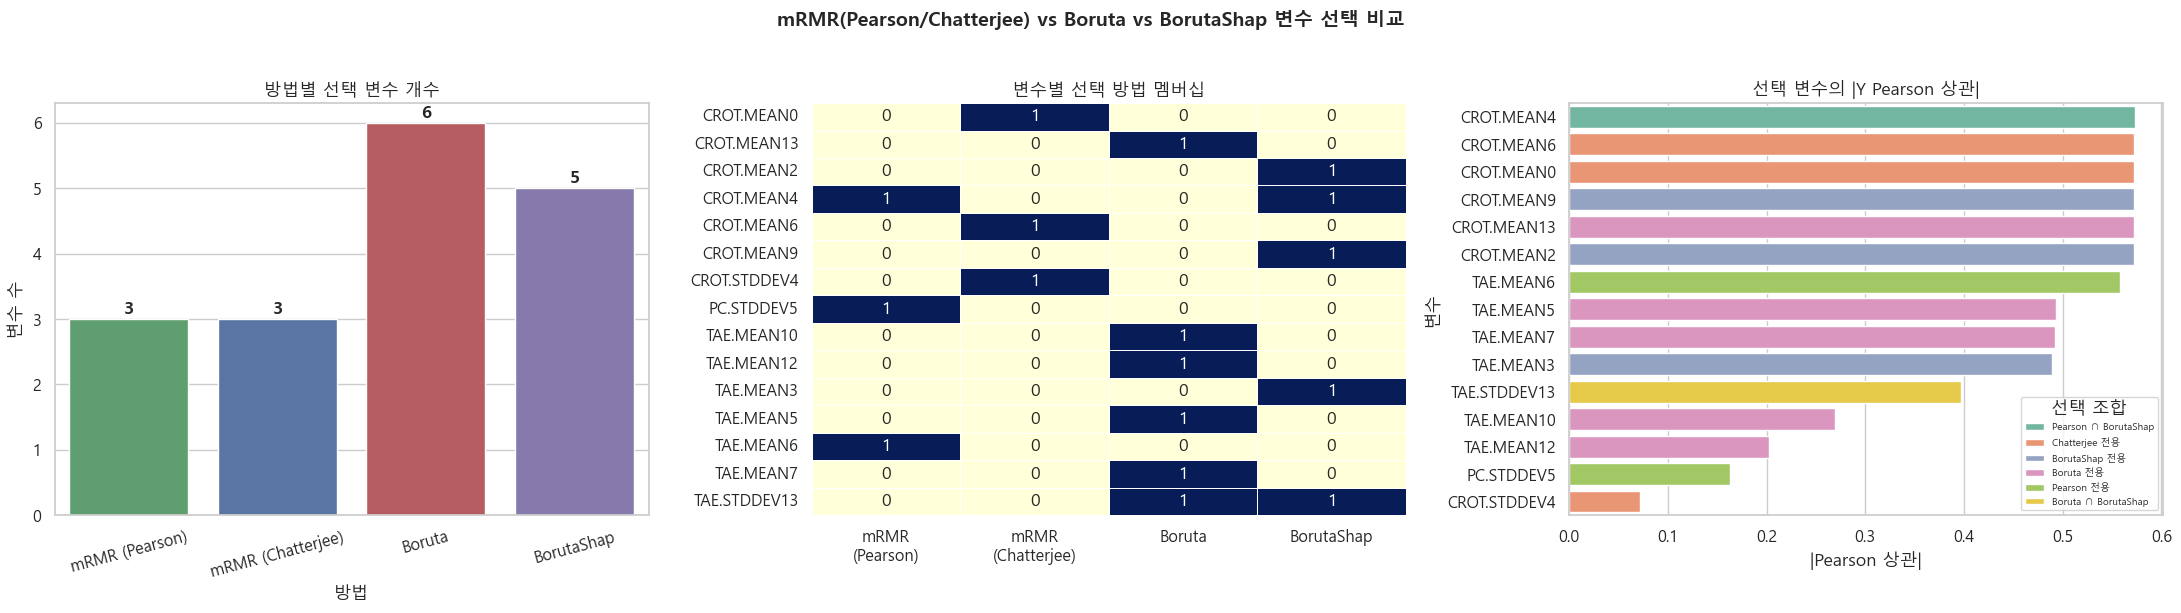


[선택 변수 간 최대 |Pearson 상관|]  Pearson mRMR: 0.363  |  Chatterjee mRMR: 1.000  |  Boruta: 1.000  |  BorutaShap: 1.000
→ Pearson mRMR은 중복 최소화 목적상 내부 상관이 낮은 편이며, Chatterjee mRMR은 Xi 기준 redundancy가 Pearson과 달라 CROT 계열 변수가 함께 선택될 수 있습니다.


In [34]:
# ============================================================
# [과제 1] mRMR(Pearson/Chatterjee) vs Boruta vs BorutaShap 비교
# - 섹션 2 + Chatterjee mRMR + BorutaShap 셀 결과 활용
# ============================================================
import matplotlib.font_manager as fm


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용 (sns.set_theme 호출 후 재호출 필요)."""
    korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in korean_fonts:
        if font in available:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

METHOD_LABELS = {
    "mrmr_pearson": "mRMR (Pearson)",
    "mrmr_xi": "mRMR (Chatterjee)",
    "boruta": "Boruta",
    "borutashap": "BorutaShap",
}

# --- 1) 네 방법의 선택 변수 집합 ---
mrmr_pearson_set = set(selected_mrmr)
mrmr_xi_set = set(selected_mrmr_xi)
boruta_set = set(selected_boruta_final)
borutashap_set = set(selected_borutashap)

all_four = sorted(mrmr_pearson_set & mrmr_xi_set & boruta_set & borutashap_set)
pearson_xi_only = sorted((mrmr_pearson_set & mrmr_xi_set) - boruta_set - borutashap_set)
pearson_boruta_only = sorted((mrmr_pearson_set & boruta_set) - mrmr_xi_set - borutashap_set)
pearson_bs_only = sorted((mrmr_pearson_set & borutashap_set) - mrmr_xi_set - boruta_set)
xi_boruta_only = sorted((mrmr_xi_set & boruta_set) - mrmr_pearson_set - borutashap_set)
xi_bs_only = sorted((mrmr_xi_set & borutashap_set) - mrmr_pearson_set - boruta_set)
boruta_bs_only = sorted((boruta_set & borutashap_set) - mrmr_pearson_set - mrmr_xi_set)

pearson_only = sorted(mrmr_pearson_set - mrmr_xi_set - boruta_set - borutashap_set)
xi_only = sorted(mrmr_xi_set - mrmr_pearson_set - boruta_set - borutashap_set)
boruta_only = sorted(boruta_set - mrmr_pearson_set - mrmr_xi_set - borutashap_set)
borutashap_only = sorted(borutashap_set - mrmr_pearson_set - mrmr_xi_set - boruta_set)

all_selected = sorted(
    mrmr_pearson_set | mrmr_xi_set | boruta_set | borutashap_set
)


def selection_label(feature):
    tags = []
    if feature in mrmr_pearson_set:
        tags.append("Pearson")
    if feature in mrmr_xi_set:
        tags.append("Chatterjee")
    if feature in boruta_set:
        tags.append("Boruta")
    if feature in borutashap_set:
        tags.append("BorutaShap")
    if len(tags) == 1:
        return f"{tags[0]} 전용"
    return " ∩ ".join(tags)


print("=" * 72)
print("[과제 1] mRMR(Pearson/Chatterjee) vs Boruta vs BorutaShap 변수 선택 비교")
print("=" * 72)
print(f"mRMR (Pearson) ({len(mrmr_pearson_set)}개, k={best_k}): {selected_mrmr}")
print(f"mRMR (Chatterjee) ({len(mrmr_xi_set)}개, k={best_k}): {selected_mrmr_xi}")
print(f"Boruta ({len(boruta_set)}개): {selected_boruta_final}")
print(f"BorutaShap ({len(borutashap_set)}개): {selected_borutashap}")
print(f"\n▶ 네 방법 공통 ({len(all_four)}개): {all_four if all_four else '없음'}")
print(f"▶ Pearson mRMR ∩ Chatterjee mRMR ({len(pearson_xi_only)}개): {pearson_xi_only if pearson_xi_only else '없음'}")
print(f"▶ Pearson mRMR ∩ Boruta ({len(pearson_boruta_only)}개): {pearson_boruta_only if pearson_boruta_only else '없음'}")
print(f"▶ Pearson mRMR ∩ BorutaShap ({len(pearson_bs_only)}개): {pearson_bs_only if pearson_bs_only else '없음'}")
print(f"▶ Chatterjee mRMR ∩ Boruta ({len(xi_boruta_only)}개): {xi_boruta_only if xi_boruta_only else '없음'}")
print(f"▶ Chatterjee mRMR ∩ BorutaShap ({len(xi_bs_only)}개): {xi_bs_only if xi_bs_only else '없음'}")
print(f"▶ Boruta ∩ BorutaShap ({len(boruta_bs_only)}개): {boruta_bs_only if boruta_bs_only else '없음'}")
print(f"▶ Pearson mRMR 전용 ({len(pearson_only)}개): {pearson_only}")
print(f"▶ Chatterjee mRMR 전용 ({len(xi_only)}개): {xi_only}")
print(f"▶ Boruta 전용 ({len(boruta_only)}개): {boruta_only}")
print(f"▶ BorutaShap 전용 ({len(borutashap_only)}개): {borutashap_only}")

# --- 2) Y와의 |Pearson 상관| (relevance 참고용) ---
corr_with_y = (
    pd.DataFrame({
        "변수": all_selected,
        "|Y 상관|": [abs(X_train[f].corr(Y_train)) for f in all_selected],
    })
    .assign(선택=lambda d: d["변수"].map(selection_label))
    .sort_values("|Y 상관|", ascending=False)
)
print("\n[선택 변수별 |Y Pearson 상관|]")
display(corr_with_y)

# --- 3) 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(all_selected) * 0.35)))

palette_methods = {
    "mRMR (Pearson)": "#55A868",
    "mRMR (Chatterjee)": "#4C72B0",
    "Boruta": "#C44E52",
    "BorutaShap": "#8172B3",
}

count_df = pd.DataFrame({
    "방법": list(palette_methods.keys()),
    "변수 수": [
        len(mrmr_pearson_set),
        len(mrmr_xi_set),
        len(boruta_set),
        len(borutashap_set),
    ],
})
sns.barplot(
    data=count_df,
    x="방법",
    y="변수 수",
    hue="방법",
    palette=palette_methods,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("방법별 선택 변수 개수")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(count_df["변수 수"]):
    axes[0].text(i, v + 0.08, str(v), ha="center", fontweight="bold")

membership = pd.DataFrame(
    {
        "mRMR\n(Pearson)": [int(f in mrmr_pearson_set) for f in all_selected],
        "mRMR\n(Chatterjee)": [int(f in mrmr_xi_set) for f in all_selected],
        "Boruta": [int(f in boruta_set) for f in all_selected],
        "BorutaShap": [int(f in borutashap_set) for f in all_selected],
    },
    index=all_selected,
)
sns.heatmap(
    membership,
    cmap="YlGnBu",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=axes[1],
)
axes[1].set_title("변수별 선택 방법 멤버십")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.barplot(
    data=corr_with_y,
    y="변수",
    x="|Y 상관|",
    hue="선택",
    dodge=False,
    ax=axes[2],
)
axes[2].set_title("선택 변수의 |Y Pearson 상관|")
axes[2].set_xlabel("|Pearson 상관|")
axes[2].legend(title="선택 조합", loc="lower right", fontsize=7)

plt.suptitle(
    "mRMR(Pearson/Chatterjee) vs Boruta vs BorutaShap 변수 선택 비교",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- 4) 선택 변수 간 중복(다중공선성) 비교 ---
def max_internal_corr(features):
    if len(features) <= 1:
        return 0
    corr = abs(X_train[features].corr())
    mask = ~np.eye(len(features), dtype=bool)
    return corr.where(mask).max().max()


mrmr_pearson_max = max_internal_corr(selected_mrmr)
mrmr_xi_max = max_internal_corr(selected_mrmr_xi)
boruta_max = max_internal_corr(selected_boruta_final)
borutashap_max = max_internal_corr(selected_borutashap)

print(
    f"\n[선택 변수 간 최대 |Pearson 상관|]  "
    f"Pearson mRMR: {mrmr_pearson_max:.3f}  |  "
    f"Chatterjee mRMR: {mrmr_xi_max:.3f}  |  "
    f"Boruta: {boruta_max:.3f}  |  "
    f"BorutaShap: {borutashap_max:.3f}"
)
print(
    "→ Pearson mRMR은 중복 최소화 목적상 내부 상관이 낮은 편이며, "
    "Chatterjee mRMR은 Xi 기준 redundancy가 Pearson과 달라 CROT 계열 변수가 함께 선택될 수 있습니다."
)

#### **[과제 1] 해석 — mRMR(Pearson/Chatterjee), Boruta, BorutaShap, 왜 다른 변수를 선택할까?**

| 구분 | mRMR Pearson (3개) | mRMR Chatterjee (3개) | Boruta (6개) | BorutaShap + CatBoost (4개) |
|---|---|---|---|---|
| 선택 변수 | CROT.MEAN4, PC.STDDEV5, TAE.MEAN6 | CROT.MEAN6, CROT.STDDEV4, CROT.MEAN0 | TAE.MEAN7, TAE.MEAN5, TAE.STDDEV13, TAE.MEAN10, TAE.MEAN12, CROT.MEAN13 | TAE.STDDEV13, CROT.MEAN9, CROT.MEAN13, CROT.MEAN4 |
| **Pearson ∩ Chatterjee mRMR** | **없음** | | | |
| **Pearson mRMR ∩ BorutaShap** | **CROT.MEAN4** | | | |
| **Boruta ∩ BorutaShap** | | | **TAE.STDDEV13, CROT.MEAN13** | |
| **네 방법 공통** | **없음** | | | |

**1) 선택 원리의 차이**

- **mRMR (Pearson)**: Relevance / Redundancy 모두 **Pearson 상관** → **선형 관계**에 민감, CV로 **k=3**.
- **mRMR (Chatterjee Xi)**: 동일 mRMR 알고리즘이지만 **Chatterjee Xi(ξ)** 로 relevance·redundancy 계산 → **단조·비선형** 의존성까지 반영. 이번 데이터에서는 **CROT 공정 변수 3개**만 선택( Pearson mRMR과 **공통 없음**).
- **Boruta**: RF 중요도 vs Shadow Feature, **All Relevant** 변수 폭넓게 포함(6개).
- **BorutaShap + CatBoost**: Shadow 구조 + **CatBoost SHAP** 중요도, RF Boruta보다 **보수적**(4개).

**2) 두 mRMR이 왜 완전히 다른가?**

- Pearson mRMR은 **PC·TAE** 등 공정을 골고루 선택하고 내부 |상관|이 낮습니다.
- Chatterjee mRMR은 Y와 Xi relevance가 **CROT 계열**에 집중되어, redundancy도 Xi 기준이라 **같은 공정(CROT) 내 변수**가 연속 선택됩니다(내부 |Pearson 상관| ≈ 1에 가까움).
- 즉 **같은 mRMR이라도 의존성 척도(Pearson vs Xi)만 바꿔도 결과가 크게 달라질 수 있음**을 보여줍니다.

**3) 방법 간 겹침**

- **Boruta ↔ BorutaShap** 공통(`TAE.STDDEV13`, `CROT.MEAN13`): Boruta 계열의 **일관된 신호**.
- **Pearson mRMR ↔ BorutaShap** 공통(`CROT.MEAN4`): CROT 공정 중요성은 일부 공유.
- **Chatterjee mRMR**은 다른 세 방법과 **교집합 없음** → Xi 기준 **CROT 초·중·후반(mean0/6, stddev4)** 에 Y 정보가 몰려 있음을 시사.

**4) 실무적 시사점**

- **선형·저중복·해석 용이** → mRMR (Pearson)
- **단조/비선형 의존성 기반 필터링** → mRMR (Chatterjee Xi) — 단, Xi redundancy 정의에 따라 **공정 내 변수가 몰릴 수 있**으므로 도메인 검토 필요
- **All-Relevant 탐색** → Boruta / BorutaShap
- 네 결과를 함께 보면 **CROT·TAE 공정**이 핵심 후보 영역이며, Chatterjee mRMR은 **CROT trace 구간별(mean index) 세부 후보**를 제시합니다.